# LOAN DEFAULT PREDICTION
Home Credit Default Risk — Kaggle Dataset
Author: Habib Bashir Lawal


# Section 1: Loading Dataset

In [1]:
# Importing required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Styling
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [2]:
# ── LOADING DATA ───────────────────────────────────────
train_df = pd.read_csv(r'C:\Users\HP\desktop\loan-default-prediction\data\application_train.csv')
test_df  = pd.read_csv(r'C:\Users\HP\desktop\loan-default-prediction\data\application_test.csv')

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [3]:
print(f"\nTraining set : {train_df.shape[0]:,} rows, {train_df.shape[1]} columns")
print(f"Test set     : {test_df.shape[0]:,} rows, {test_df.shape[1]} columns")
print(f"\nTarget column distribution:")
print(train_df['TARGET'].value_counts())
print(f"\nDefault rate : {train_df['TARGET'].mean()*100:.2f}%")


Training set : 307,511 rows, 122 columns
Test set     : 48,744 rows, 121 columns

Target column distribution:
TARGET
0    282686
1     24825
Name: count, dtype: int64

Default rate : 8.07%


# Section 2: Exploratory Data Analysis

In [4]:
print("DATASET OVERVIEW")


print(f"\nShape: {train_df.shape}")
print(f"\nColumn Data Types:")
print(train_df.dtypes.value_counts())
print(f"\nFirst 5 rows:")
train_df.head()

DATASET OVERVIEW

Shape: (307511, 122)

Column Data Types:
float64    65
int64      41
object     16
Name: count, dtype: int64

First 5 rows:


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Missing values-Major problem of this dataset
missing = train_df.isnull().sum()
missing_pct = (missing / len(train_df)) * 100
missing_df = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

In [6]:
# Show only columns with missing values
missing_df = missing_df[missing_df['missing_count'] > 0]

print(f"Total columns with missing values: {len(missing_df)}")
print(f"\nTop 20 columns with most missing values:")
print(missing_df.head(20).to_string())

Total columns with missing values: 67

Top 20 columns with most missing values:
                          missing_count  missing_pct
COMMONAREA_MEDI                  214865    69.872297
COMMONAREA_AVG                   214865    69.872297
COMMONAREA_MODE                  214865    69.872297
NONLIVINGAPARTMENTS_MODE         213514    69.432963
NONLIVINGAPARTMENTS_AVG          213514    69.432963
NONLIVINGAPARTMENTS_MEDI         213514    69.432963
FONDKAPREMONT_MODE               210295    68.386172
LIVINGAPARTMENTS_MODE            210199    68.354953
LIVINGAPARTMENTS_AVG             210199    68.354953
LIVINGAPARTMENTS_MEDI            210199    68.354953
FLOORSMIN_AVG                    208642    67.848630
FLOORSMIN_MODE                   208642    67.848630
FLOORSMIN_MEDI                   208642    67.848630
YEARS_BUILD_MEDI                 204488    66.497784
YEARS_BUILD_MODE                 204488    66.497784
YEARS_BUILD_AVG                  204488    66.497784
OWN_CAR_AGE        

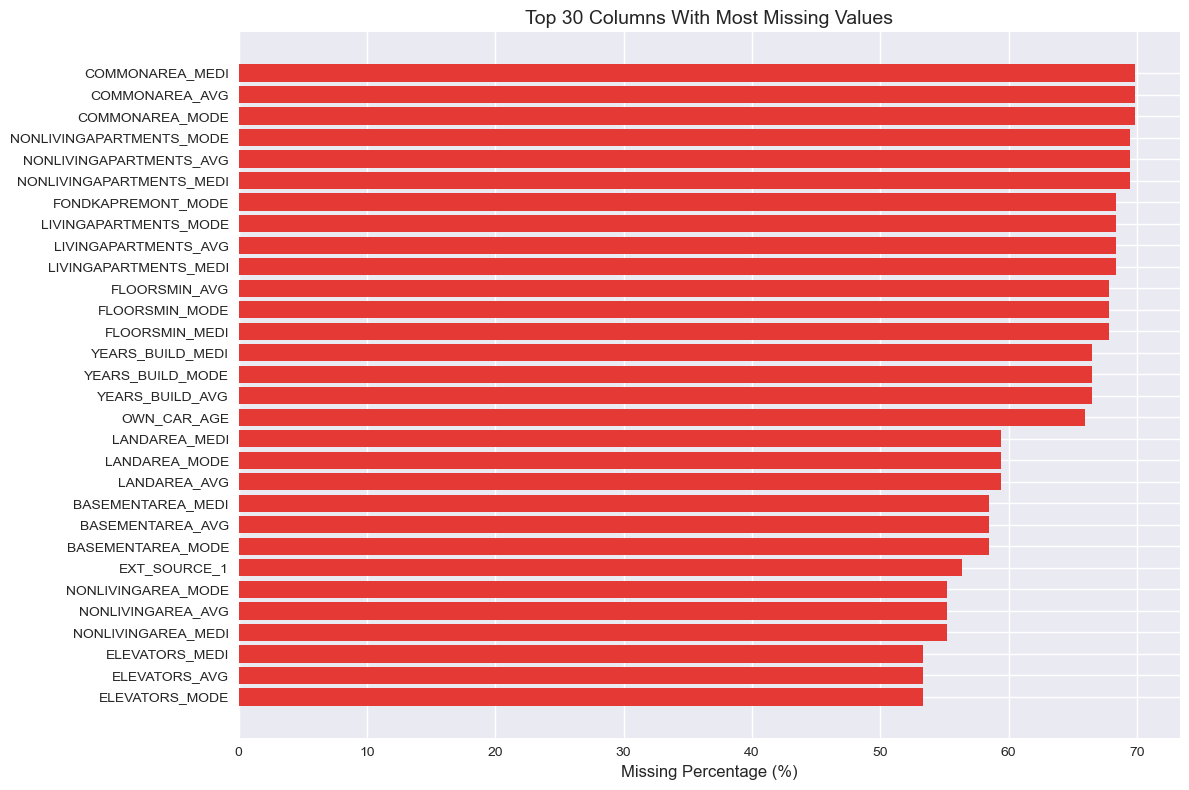


Columns with more than 50% missing: 41
Columns with more than 30% missing: 50


In [7]:
# Lets Visualize top 30 missing columns
top_missing = missing_df.head(30)

plt.figure(figsize=(12, 8))
bars = plt.barh(top_missing.index, top_missing['missing_pct'],
                color='#e53935')
plt.xlabel('Missing Percentage (%)', fontsize=12)
plt.title('Top 30 Columns With Most Missing Values', fontsize=14)
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"\nColumns with more than 50% missing: "
      f"{len(missing_df[missing_df['missing_pct'] > 50])}")
print(f"Columns with more than 30% missing: "
      f"{len(missing_df[missing_df['missing_pct'] > 30])}")

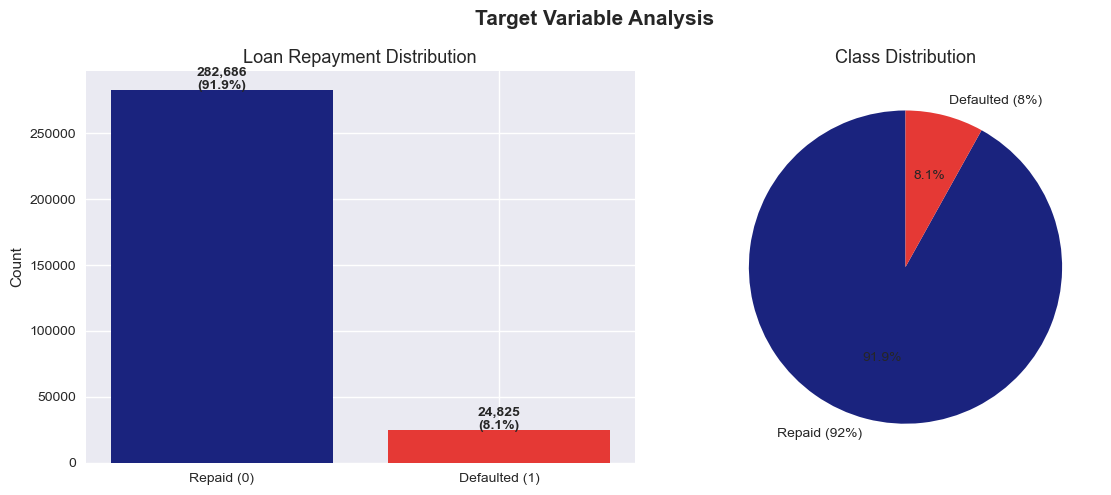


Key Insight: Severe class imbalance — 92% repaid vs 8% defaulted
This means accuracy alone is going to mislead as a metric
So We will use AUC-ROC, Precision, and Recall instead


In [8]:
# TARGET VARIABLE Distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Count plot
counts = train_df['TARGET'].value_counts()
axes[0].bar(['Repaid (0)', 'Defaulted (1)'],
            counts.values,
            color=['#1a237e', '#e53935'])
axes[0].set_title('Loan Repayment Distribution', fontsize=13)
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 500, f'{v:,}\n({v/len(train_df)*100:.1f}%)',
                 ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values,
            labels=['Repaid (92%)', 'Defaulted (8%)'],
            colors=['#1a237e', '#e53935'],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Class Distribution', fontsize=13)

plt.suptitle('Target Variable Analysis', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nKey Insight: Severe class imbalance — 92% repaid vs 8% defaulted")
print("This means accuracy alone is going to mislead as a metric")
print("So We will use AUC-ROC, Precision, and Recall instead")

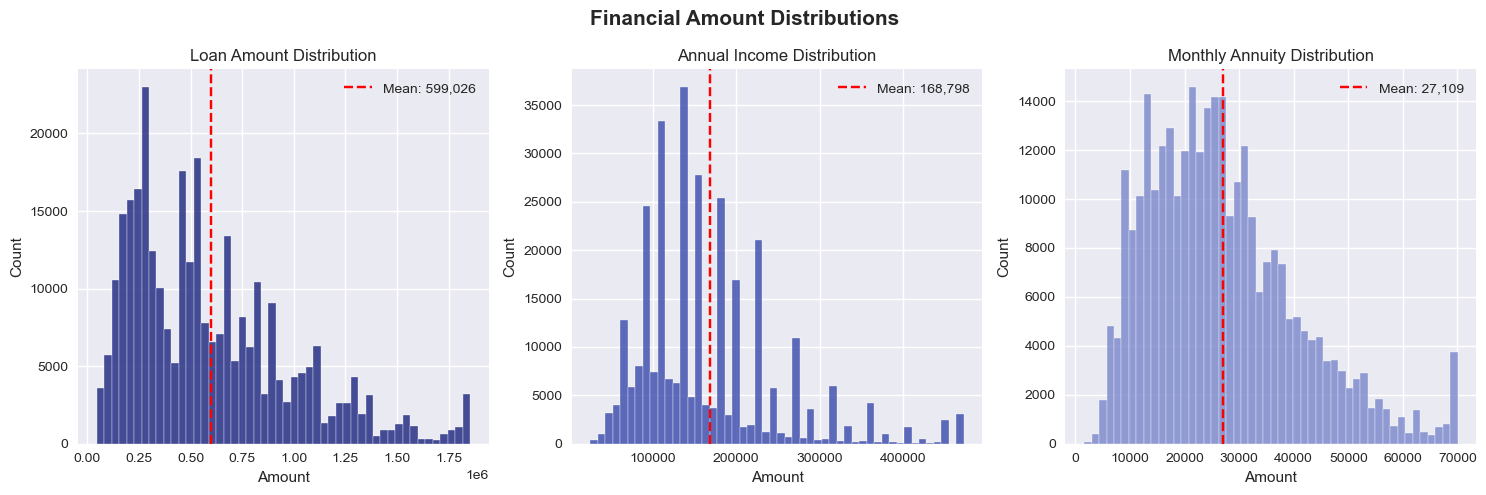


Financial Summary Statistics:
       AMT_CREDIT  AMT_INCOME_TOTAL  AMT_ANNUITY
count   307511.00      3.075110e+05    307499.00
mean    599026.00      1.687979e+05     27108.57
std     402490.78      2.371231e+05     14493.74
min      45000.00      2.565000e+04      1615.50
25%     270000.00      1.125000e+05     16524.00
50%     513531.00      1.471500e+05     24903.00
75%     808650.00      2.025000e+05     34596.00
max    4050000.00      1.170000e+08    258025.50


In [9]:
# LOAN AMOUNTS Analysis
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

amount_cols = ['AMT_CREDIT', 'AMT_INCOME_TOTAL', 'AMT_ANNUITY']
titles      = ['Loan Amount', 'Annual Income', 'Monthly Annuity']
colors      = ['#1a237e', '#3949ab', '#7986cb']

for i, (col, title, color) in enumerate(
        zip(amount_cols, titles, colors)):
    axes[i].hist(
        train_df[col].dropna().clip(
            upper=train_df[col].quantile(0.99)),
        bins=50, color=color, alpha=0.8, edgecolor='white')
    axes[i].set_title(f'{title} Distribution', fontsize=12)
    axes[i].set_xlabel('Amount')
    axes[i].set_ylabel('Count')
    mean_val = train_df[col].mean()
    axes[i].axvline(mean_val, color='red',
                    linestyle='--', label=f'Mean: {mean_val:,.0f}')
    axes[i].legend()

plt.suptitle('Financial Amount Distributions', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nFinancial Summary Statistics:")
print(train_df[amount_cols].describe().round(2).to_string())

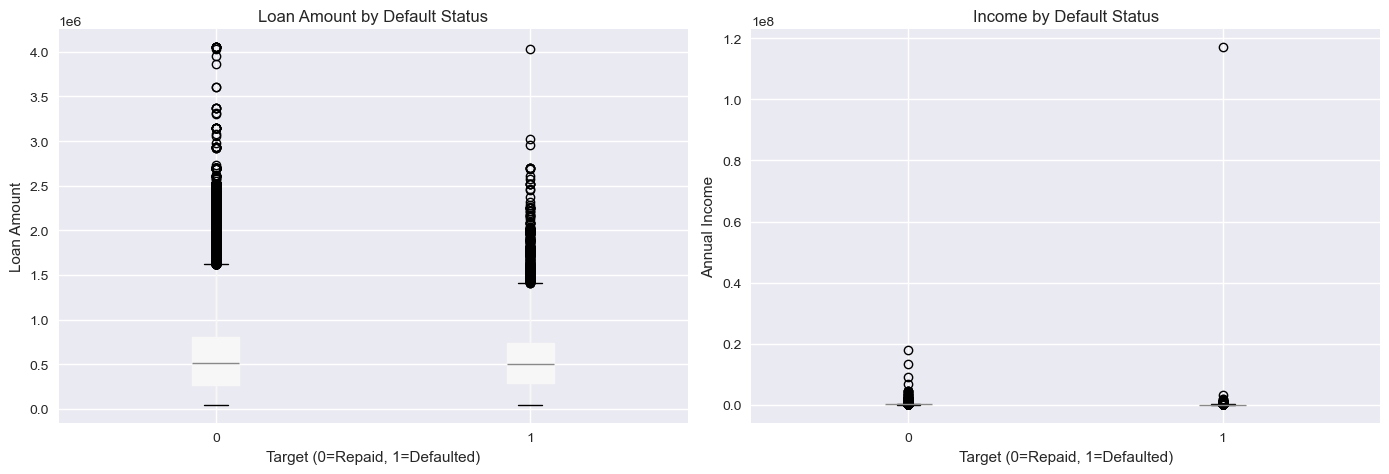


Average Loan Amount:
TARGET
0    602648.28
1    557778.53
Name: AMT_CREDIT, dtype: float64

Average Income:
TARGET
0    169077.72
1    165611.76
Name: AMT_INCOME_TOTAL, dtype: float64


In [10]:
# Does loan amount relate to default? lets see loan amount vs defalut
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit amount by target
train_df.boxplot(column='AMT_CREDIT', by='TARGET',
                 ax=axes[0], patch_artist=True)
axes[0].set_title('Loan Amount by Default Status')
axes[0].set_xlabel('Target (0=Repaid, 1=Defaulted)')
axes[0].set_ylabel('Loan Amount')

# Income by target
train_df.boxplot(column='AMT_INCOME_TOTAL', by='TARGET',
                 ax=axes[1], patch_artist=True)
axes[1].set_title('Income by Default Status')
axes[1].set_xlabel('Target (0=Repaid, 1=Defaulted)')
axes[1].set_ylabel('Annual Income')

plt.suptitle('')
plt.tight_layout()
plt.show()

print("\nAverage Loan Amount:")
print(train_df.groupby('TARGET')['AMT_CREDIT'].mean().round(2))
print("\nAverage Income:")
print(train_df.groupby('TARGET')['AMT_INCOME_TOTAL'].mean().round(2))

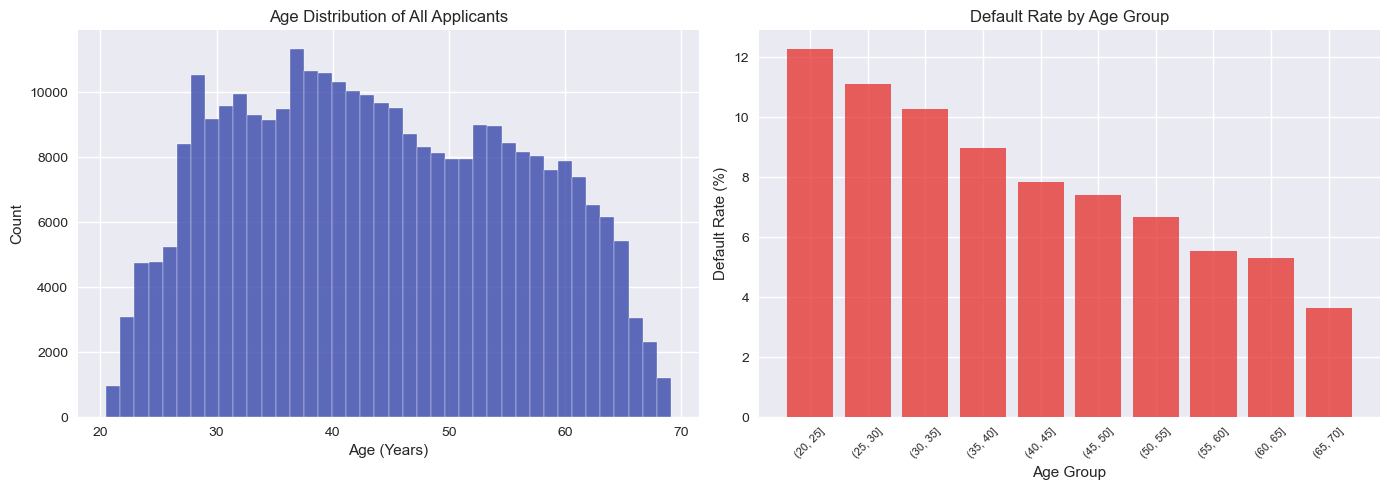


Key Insight: Younger applicants tend to have higher default rates

Default rate by age group:
AGE_YEARS
(20, 25]    12.27
(25, 30]    11.11
(30, 35]    10.26
(35, 40]     8.98
(40, 45]     7.83
(45, 50]     7.41
(50, 55]     6.68
(55, 60]     5.53
(60, 65]     5.29
(65, 70]     3.65


In [11]:
#Age Analysis
# DAYS_BIRTH is negative — convert to age in years
train_df['AGE_YEARS'] = (-train_df['DAYS_BIRTH'] / 365).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution
axes[0].hist(train_df['AGE_YEARS'], bins=40,
             color='#3949ab', alpha=0.8, edgecolor='white')
axes[0].set_title('Age Distribution of All Applicants', fontsize=12)
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Count')

# Age vs default rate
age_bins   = pd.cut(train_df['AGE_YEARS'], bins=range(20, 75, 5))
age_default = train_df.groupby(age_bins)['TARGET'].mean() * 100

axes[1].bar(range(len(age_default)),
            age_default.values, color='#e53935', alpha=0.8)
axes[1].set_xticks(range(len(age_default)))
axes[1].set_xticklabels(
    [str(x) for x in age_default.index], rotation=45, fontsize=8)
axes[1].set_title('Default Rate by Age Group', fontsize=12)
axes[1].set_xlabel('Age Group')
axes[1].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

print("\nKey Insight: Younger applicants tend to have higher default rates")
print(f"\nDefault rate by age group:")
print(age_default.round(2).to_string())

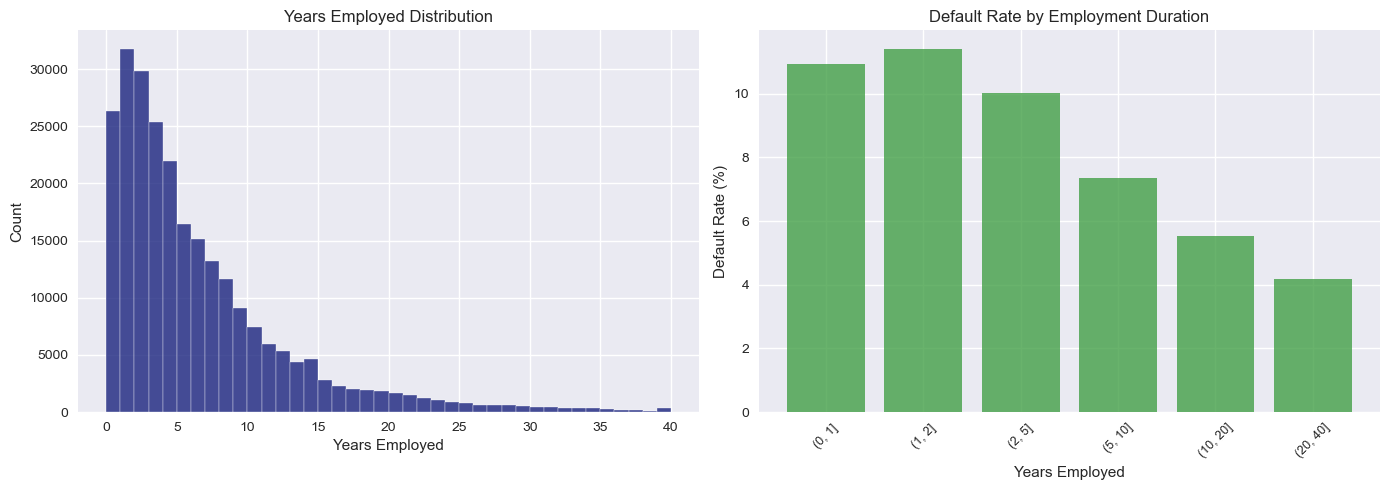


Key Insight: Shorter employment duration = higher default risk

Default rate by employment duration:
YEARS_EMPLOYED
(0, 1]      10.95
(1, 2]      11.42
(2, 5]      10.03
(5, 10]      7.35
(10, 20]     5.52
(20, 40]     4.19


In [12]:
#Employment Analysis
# DAYS_EMPLOYED — convert to years
# Note: 365243 is a magic number meaning unemployed/retired
train_df['DAYS_EMPLOYED_CLEAN'] = train_df['DAYS_EMPLOYED'].replace(
    365243, np.nan)
train_df['YEARS_EMPLOYED'] = (
    -train_df['DAYS_EMPLOYED_CLEAN'] / 365).round(1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Employment duration distribution
axes[0].hist(
    train_df['YEARS_EMPLOYED'].dropna().clip(upper=40),
    bins=40, color='#1a237e', alpha=0.8, edgecolor='white')
axes[0].set_title('Years Employed Distribution', fontsize=12)
axes[0].set_xlabel('Years Employed')
axes[0].set_ylabel('Count')

# Employment vs default rate
emp_bins    = pd.cut(
    train_df['YEARS_EMPLOYED'].clip(upper=40),
    bins=[0, 1, 2, 5, 10, 20, 40])
emp_default = train_df.groupby(emp_bins)['TARGET'].mean() * 100

axes[1].bar(range(len(emp_default)),
            emp_default.values, color='#43a047', alpha=0.8)
axes[1].set_xticks(range(len(emp_default)))
axes[1].set_xticklabels(
    [str(x) for x in emp_default.index], rotation=45, fontsize=9)
axes[1].set_title('Default Rate by Employment Duration', fontsize=12)
axes[1].set_xlabel('Years Employed')
axes[1].set_ylabel('Default Rate (%)')

plt.tight_layout()
plt.show()

print("\nKey Insight: Shorter employment duration = higher default risk")
print(f"\nDefault rate by employment duration:")
print(emp_default.round(2).to_string())

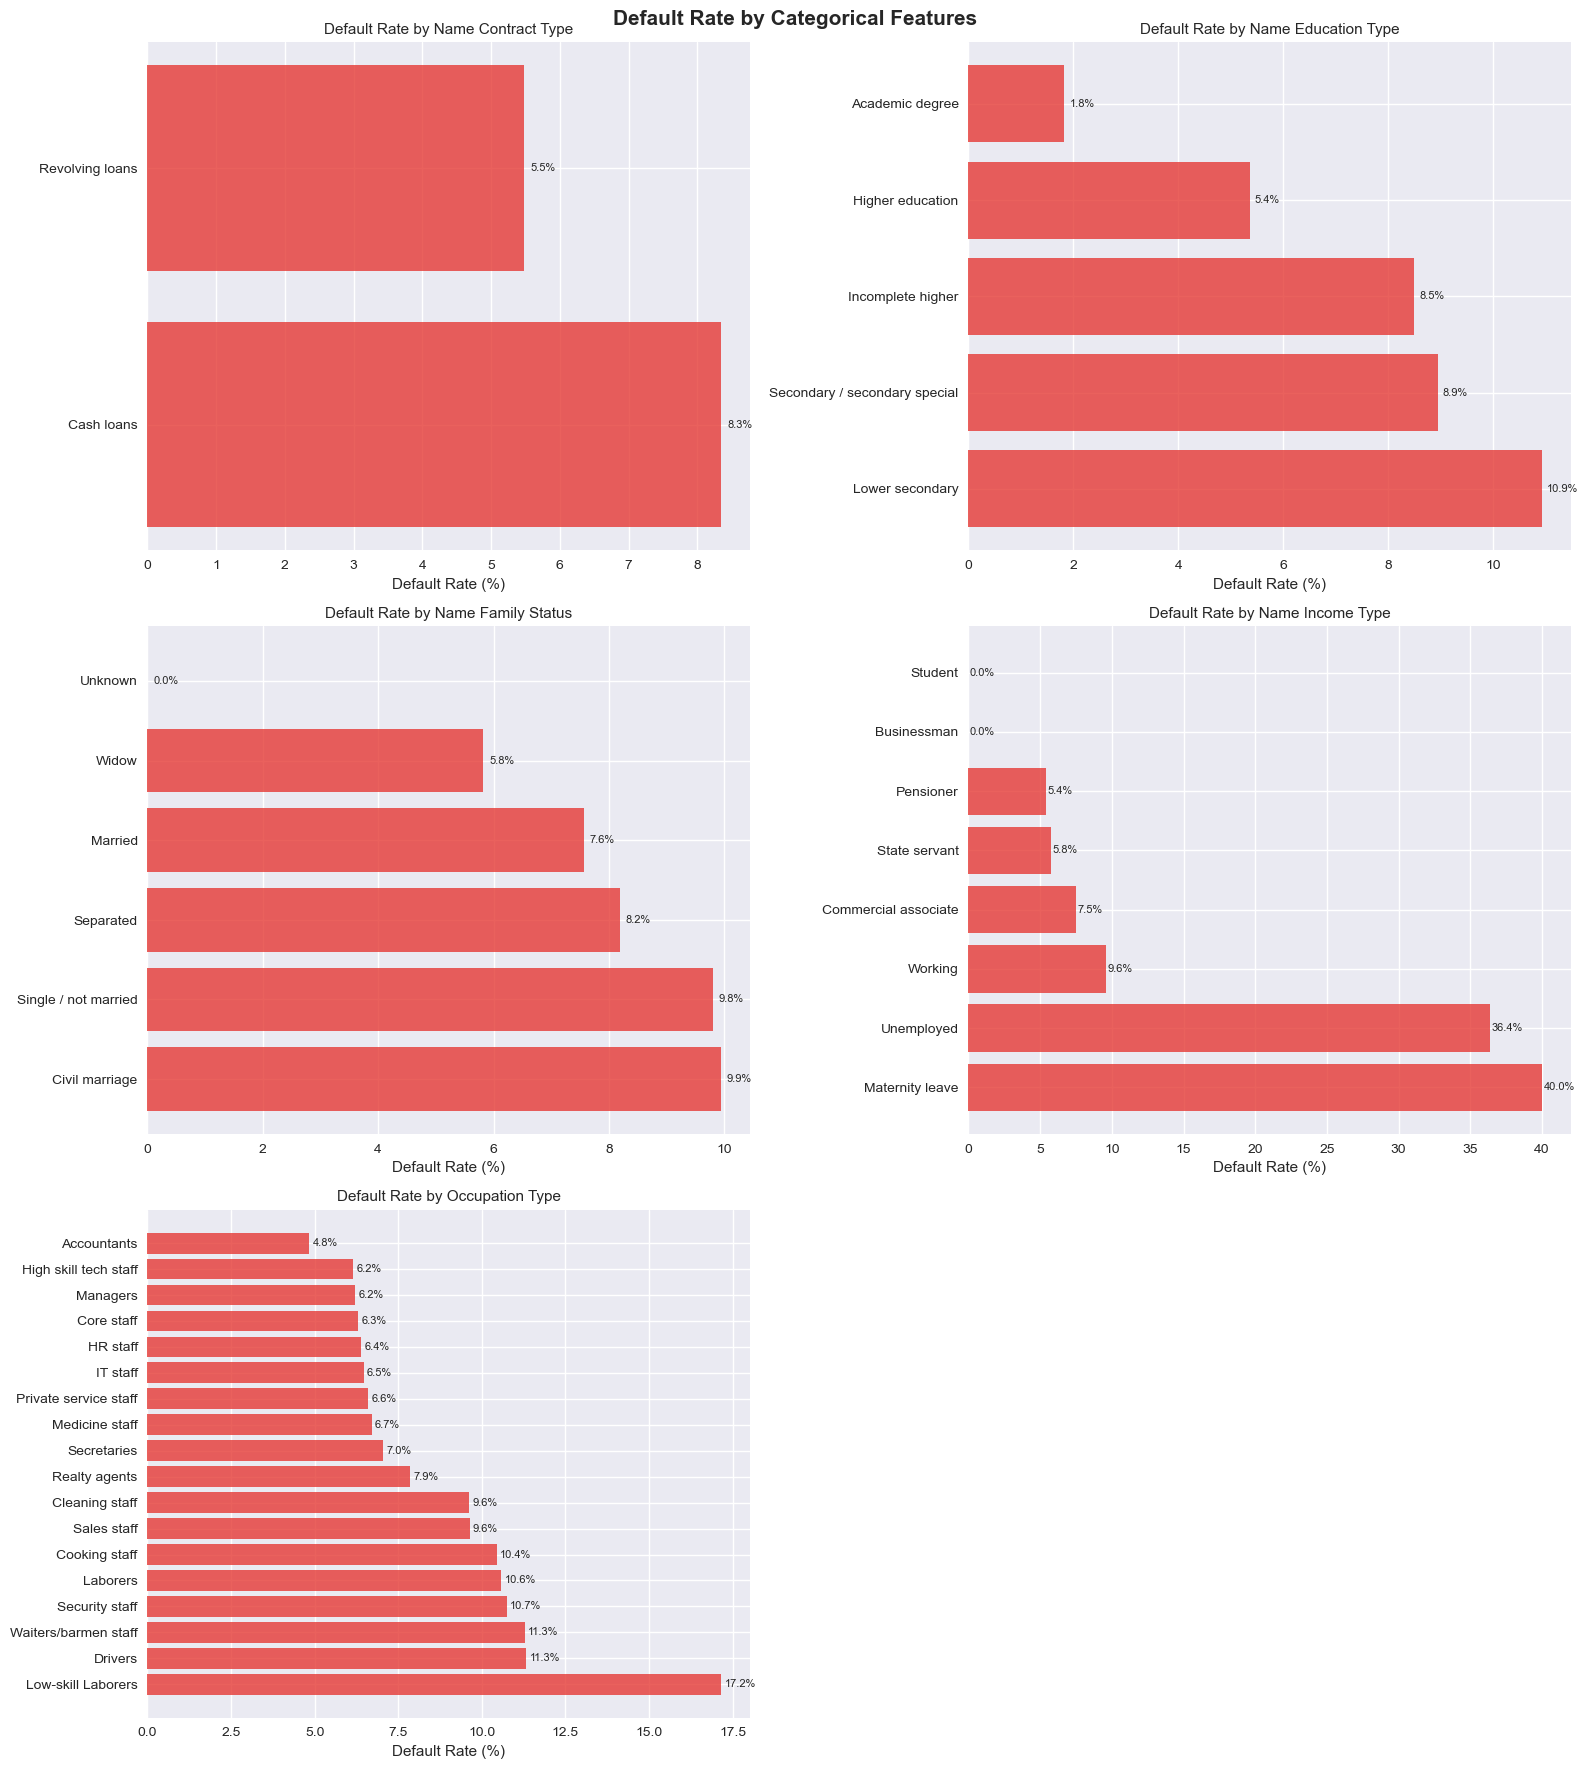

In [13]:
# CATEGORICAL FEATURES ANALYSIS
cat_cols = [
    'NAME_CONTRACT_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_INCOME_TYPE',
    'OCCUPATION_TYPE'
]

fig, axes = plt.subplots(3, 2, figsize=(16, 18))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    default_rate = train_df.groupby(col)['TARGET'].mean() * 100
    default_rate = default_rate.sort_values(ascending=False)

    bars = axes[i].barh(
        default_rate.index,
        default_rate.values,
        color='#e53935', alpha=0.8)
    axes[i].set_title(
        f'Default Rate by {col.replace("_", " ").title()}',
        fontsize=11)
    axes[i].set_xlabel('Default Rate (%)')

    for bar, val in zip(bars, default_rate.values):
        axes[i].text(val + 0.1, bar.get_y() + bar.get_height()/2,
                     f'{val:.1f}%', va='center', fontsize=8)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.suptitle('Default Rate by Categorical Features',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

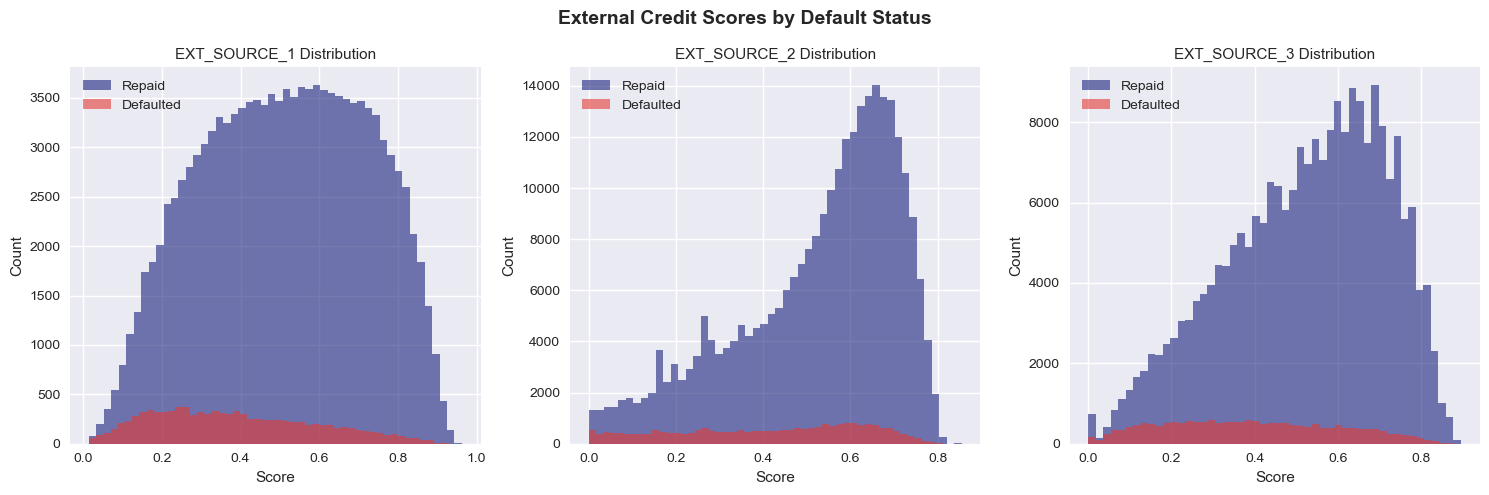


Correlation of External Scores with Default:
  EXT_SOURCE_1: -0.1553
  EXT_SOURCE_2: -0.1605
  EXT_SOURCE_3: -0.1789

Key Insight: Lower external credit scores = higher default risk
EXT_SOURCE_2 and EXT_SOURCE_3 are likely top predictive features


In [14]:
#EXTERNAL CREDIT SCORE
# EXT_SOURCE_1, 2, 3 are external credit scores
# These are usually the most predictive features
ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for i, col in enumerate(ext_cols):
    # Plot distribution by target
    axes[i].hist(
        train_df[train_df['TARGET']==0][col].dropna(),
        bins=50, alpha=0.6, color='#1a237e', label='Repaid')
    axes[i].hist(
        train_df[train_df['TARGET']==1][col].dropna(),
        bins=50, alpha=0.6, color='#e53935', label='Defaulted')
    axes[i].set_title(f'{col} Distribution', fontsize=11)
    axes[i].set_xlabel('Score')
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('External Credit Scores by Default Status',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\nCorrelation of External Scores with Default:")
for col in ext_cols:
    corr = train_df[col].corr(train_df['TARGET'])
    print(f"  {col}: {corr:.4f}")

print("\nKey Insight: Lower external credit scores = higher default risk")
print("EXT_SOURCE_2 and EXT_SOURCE_3 are likely top predictive features")

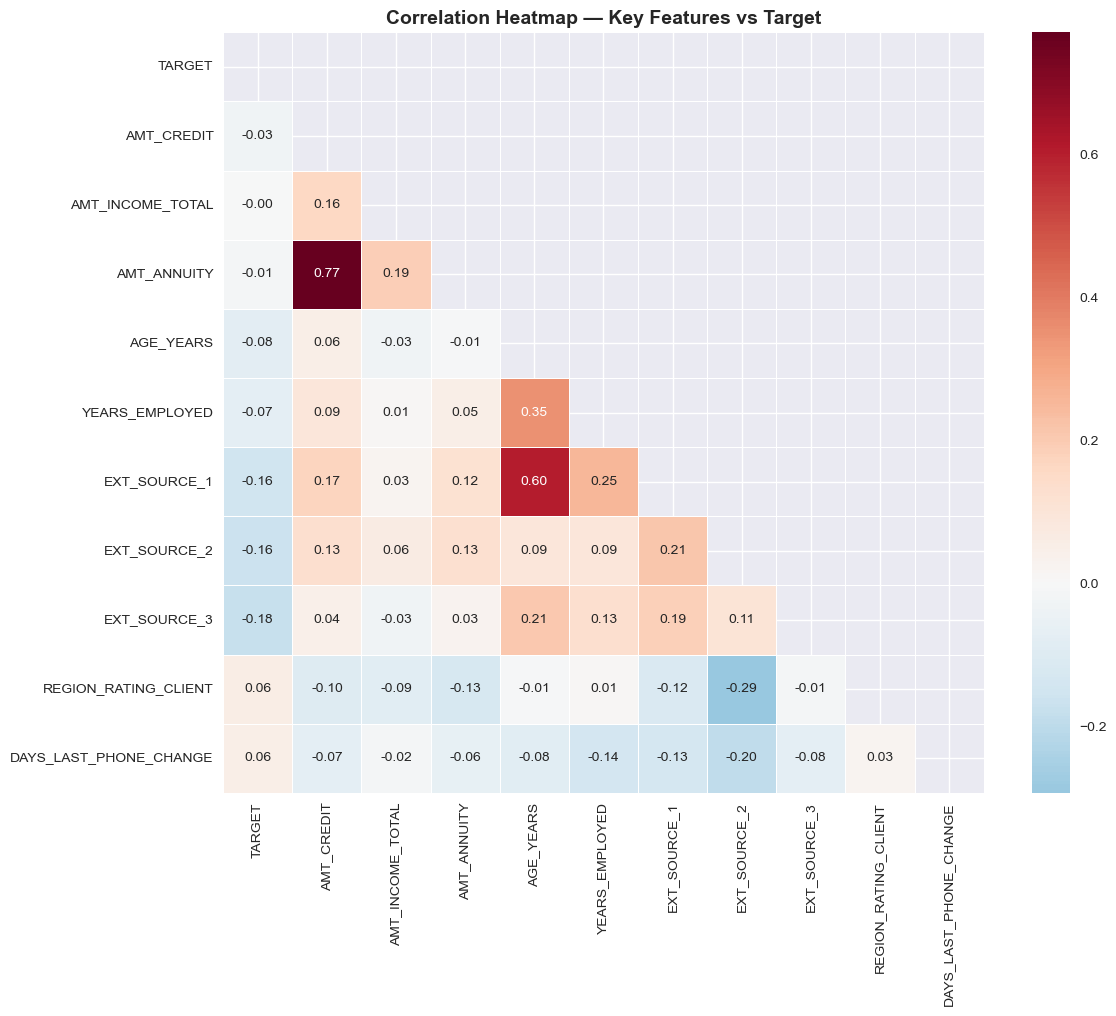

In [15]:
# Correlation of numerical features with TARGET
num_cols = [
    'TARGET', 'AMT_CREDIT', 'AMT_INCOME_TOTAL',
    'AMT_ANNUITY', 'AGE_YEARS', 'YEARS_EMPLOYED',
    'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3',
    'REGION_RATING_CLIENT', 'DAYS_LAST_PHONE_CHANGE'
]

corr_matrix = train_df[num_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True,
            fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Key Features vs Target',
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [16]:
# EDA SUMMARY
print("=" * 55)
print("EDA SUMMARY — KEY FINDINGS")
print("=" * 55)

print("""
1. CLASS IMBALANCE
   Only 8.07% of loans defaulted — severe imbalance.
   Cannot use accuracy as evaluation metric.
   Will use AUC-ROC, Precision, and Recall.

2. MISSING VALUES
   Many columns have 40-70% missing values.
   Will drop columns with more than 50% missing.
   Will impute remaining with median/mode.

3. AGE MATTERS
   Younger applicants (20-30) default more often.
   Will engineer AGE_YEARS as a clean feature.

4. EMPLOYMENT STABILITY MATTERS
   Shorter employment duration = higher default risk.
   The value 365243 in DAYS_EMPLOYED means unemployed.
   Will clean and engineer YEARS_EMPLOYED.

5. EXTERNAL CREDIT SCORES ARE POWERFUL
   EXT_SOURCE_2 and EXT_SOURCE_3 strongly correlate
   with default. These will be top model features.

6. LOAN TO INCOME RATIO
   Defaulters tend to borrow more relative to income.
   Will engineer AMT_CREDIT / AMT_INCOME_TOTAL ratio.
""")

EDA SUMMARY — KEY FINDINGS

1. CLASS IMBALANCE
   Only 8.07% of loans defaulted — severe imbalance.
   Cannot use accuracy as evaluation metric.
   Will use AUC-ROC, Precision, and Recall.

2. MISSING VALUES
   Many columns have 40-70% missing values.
   Will drop columns with more than 50% missing.
   Will impute remaining with median/mode.

3. AGE MATTERS
   Younger applicants (20-30) default more often.
   Will engineer AGE_YEARS as a clean feature.

4. EMPLOYMENT STABILITY MATTERS
   Shorter employment duration = higher default risk.
   The value 365243 in DAYS_EMPLOYED means unemployed.
   Will clean and engineer YEARS_EMPLOYED.

5. EXTERNAL CREDIT SCORES ARE POWERFUL
   EXT_SOURCE_2 and EXT_SOURCE_3 strongly correlate
   with default. These will be top model features.

6. LOAN TO INCOME RATIO
   Defaulters tend to borrow more relative to income.
   Will engineer AMT_CREDIT / AMT_INCOME_TOTAL ratio.



# Section 3: Data Preprocessing

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

print("Starting preprocessing pipeline...")
print(f"Original shape: {train_df.shape}")

Starting preprocessing pipeline...
Original shape: (307511, 125)


In [18]:
# Lets Drop columns with more than 50% missing values
# These columns have too little data to be useful
threshold    = 0.5
missing_pct  = train_df.isnull().mean()
cols_to_drop = missing_pct[missing_pct > threshold].index.tolist()

train_df = train_df.drop(columns=cols_to_drop)
test_df  = test_df.drop(
    columns=[c for c in cols_to_drop if c in test_df.columns])

print(f"Columns dropped (>50% missing) : {len(cols_to_drop)}")
print(f"Remaining columns              : {train_df.shape[1]}")

Columns dropped (>50% missing) : 41
Remaining columns              : 84


In [19]:
# lets clean Anonymous Value
# Fix DAYS_EMPLOYED anomaly
# 365243 means unemployed/retired — replace with NaN
train_df['DAYS_EMPLOYED'] = train_df['DAYS_EMPLOYED'].replace(
    365243, np.nan)
test_df['DAYS_EMPLOYED']  = test_df['DAYS_EMPLOYED'].replace(
    365243, np.nan)

# Fix negative days — convert to positive years
train_df['AGE_YEARS']      = (-train_df['DAYS_BIRTH']    / 365).round(1)
train_df['YEARS_EMPLOYED'] = (-train_df['DAYS_EMPLOYED'] / 365).round(1)
test_df['AGE_YEARS']       = (-test_df['DAYS_BIRTH']     / 365).round(1)
test_df['YEARS_EMPLOYED']  = (-test_df['DAYS_EMPLOYED']  / 365).round(1)

print("Anomalous values cleaned.")
print(f"  AGE_YEARS range      : {train_df['AGE_YEARS'].min():.0f} to {train_df['AGE_YEARS'].max():.0f} years")
print(f"  YEARS_EMPLOYED range : {train_df['YEARS_EMPLOYED'].min():.1f} to {train_df['YEARS_EMPLOYED'].max():.1f} years")

Anomalous values cleaned.
  AGE_YEARS range      : 20 to 69 years
  YEARS_EMPLOYED range : 0.0 to 49.1 years


In [20]:
# Separating target from features
TARGET = 'TARGET'
y      = train_df[TARGET]
X      = train_df.drop(columns=[TARGET])

# Remove ID column — not a feature
ID_COL = 'SK_ID_CURR'
X      = X.drop(columns=[ID_COL])
test_X = test_df.drop(
    columns=[ID_COL] if ID_COL in test_df.columns else [])

print(f"Features shape : {X.shape}")
print(f"Target shape   : {y.shape}")
print(f"Default rate   : {y.mean()*100:.2f}%")

Features shape : (307511, 82)
Target shape   : (307511,)
Default rate   : 8.07%


In [21]:
# Lets Identify and handle categorical columns
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()

print(f"Categorical columns : {len(cat_cols)}")
print(f"Numerical columns   : {len(num_cols)}")
print(f"\nCategorical columns:")
for c in cat_cols:
    print(f"  {c} — {X[c].nunique()} unique values")

Categorical columns : 13
Numerical columns   : 69

Categorical columns:
  NAME_CONTRACT_TYPE — 2 unique values
  CODE_GENDER — 3 unique values
  FLAG_OWN_CAR — 2 unique values
  FLAG_OWN_REALTY — 2 unique values
  NAME_TYPE_SUITE — 7 unique values
  NAME_INCOME_TYPE — 8 unique values
  NAME_EDUCATION_TYPE — 5 unique values
  NAME_FAMILY_STATUS — 6 unique values
  NAME_HOUSING_TYPE — 6 unique values
  OCCUPATION_TYPE — 18 unique values
  WEEKDAY_APPR_PROCESS_START — 7 unique values
  ORGANIZATION_TYPE — 58 unique values
  EMERGENCYSTATE_MODE — 2 unique values


In [22]:
# Lets Encode categorical Values
# Label encode all categorical columns
# For binary columns (Y/N) this is perfect
# For multi-value columns XGBoost handles this well
le        = LabelEncoder()
encoders  = {}

for col in cat_cols:
    # Fill missing before encoding
    X[col]      = X[col].fillna('Unknown')
    test_X[col] = test_X[col].fillna('Unknown') \
        if col in test_X.columns else test_X[col]

    # Fit on train and transform both
    le.fit(X[col])
    X[col] = le.transform(X[col])

    # Handle unseen categories in test
    if col in test_X.columns:
        test_X[col] = test_X[col].apply(
            lambda x: x if x in le.classes_ else 'Unknown')
        test_X[col] = le.transform(test_X[col])

    encoders[col] = le

print("All categorical columns encoded successfully.")

All categorical columns encoded successfully.


In [23]:
# Before the imputation cell, drop the redundant column
if 'DAYS_EMPLOYED_CLEAN' in X.columns:
    X = X.drop(columns=['DAYS_EMPLOYED_CLEAN'])
    num_cols = [c for c in num_cols if c != 'DAYS_EMPLOYED_CLEAN']

In [24]:
#Now lets inpute missing numerical values
from sklearn.impute import SimpleImputer

# Use median imputation for numerical columns
# Median is better than mean for skewed financial data
imputer    = SimpleImputer(strategy='median')
X[num_cols]       = imputer.fit_transform(X[num_cols])
test_X_num_cols   = [c for c in num_cols if c in test_X.columns]
test_X[test_X_num_cols] = imputer.transform(
    test_X[test_X_num_cols])

print(f"Missing values after imputation:")
print(f"  Train : {X.isnull().sum().sum()}")
print(f"  Test  : {test_X.isnull().sum().sum()}")
print("\nPreprocessing complete — no missing values remain.")

Missing values after imputation:
  Train : 0
  Test  : 0

Preprocessing complete — no missing values remain.


In [25]:
# Now train test split
# Split training data into train and validation sets
# Stratify ensures same class ratio in both splits
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train/Validation split complete:")
print(f"  Training set   : {X_train.shape[0]:,} rows")
print(f"  Validation set : {X_val.shape[0]:,} rows")
print(f"  Features       : {X_train.shape[1]}")
print(f"\nDefault rate in training   : {y_train.mean()*100:.2f}%")
print(f"Default rate in validation : {y_val.mean()*100:.2f}%")

Train/Validation split complete:
  Training set   : 246,008 rows
  Validation set : 61,503 rows
  Features       : 81

Default rate in training   : 8.07%
Default rate in validation : 8.07%


# Section 4: Feature Engineering

In [26]:
# Creating new meaningful features from existing ones.
# Good features often matter more than model choice.

print("Starting feature engineering...")
print(f"Current feature count: {X_train.shape[1]}")

Starting feature engineering...
Current feature count: 81


In [27]:
# Creating New Features
def engineer_features(df):
    """
    Creates new features that capture relationships
    the model cannot easily discover on its own.
    Each feature has a clear business meaning.
    """
    df = df.copy()

    # 1. Credit to Income Ratio
    # How much loan relative to annual income?
    # Higher ratio = more financial stress = higher risk
    df['CREDIT_INCOME_RATIO'] = (
        df['AMT_CREDIT'] /
        (df['AMT_INCOME_TOTAL'] + 1)
    ).round(4)

    # 2. Annuity to Income Ratio
    # What percentage of income goes to monthly payments?
    # Higher = harder to repay
    df['ANNUITY_INCOME_RATIO'] = (
        df['AMT_ANNUITY'] /
        (df['AMT_INCOME_TOTAL'] + 1)
    ).round(4)

    # 3. Credit Term
    # How many months to repay the loan?
    # Longer term = more risk exposure
    df['CREDIT_TERM'] = (
        df['AMT_CREDIT'] /
        (df['AMT_ANNUITY'] + 1)
    ).round(1)

    # 4. Days Employed to Age Ratio
    # What fraction of their life have they been employed?
    # Higher = more stable employment history
    if 'DAYS_BIRTH' in df.columns and 'DAYS_EMPLOYED' in df.columns:
        df['EMPLOYED_TO_AGE_RATIO'] = (
            df['DAYS_EMPLOYED'] /
            (df['DAYS_BIRTH'] + 1)
        ).round(4)

    # 5. Income per Family Member
    # Income relative to family size
    if 'CNT_FAM_MEMBERS' in df.columns:
        df['INCOME_PER_FAMILY_MEMBER'] = (
            df['AMT_INCOME_TOTAL'] /
            (df['CNT_FAM_MEMBERS'] + 1)
        ).round(2)

    # 6. External Score Average
    # Average of all three external credit scores
    ext_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
    available = [c for c in ext_cols if c in df.columns]
    if available:
        df['EXT_SOURCE_MEAN'] = df[available].mean(axis=1).round(4)
        df['EXT_SOURCE_MIN']  = df[available].min(axis=1).round(4)
        df['EXT_SOURCE_MAX']  = df[available].max(axis=1).round(4)

    return df

# Apply to all splits
X_train = engineer_features(X_train)
X_val   = engineer_features(X_val)
test_X  = engineer_features(test_X)

new_features = [
    'CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO',
    'CREDIT_TERM', 'EXT_SOURCE_MEAN',
    'EXT_SOURCE_MIN', 'EXT_SOURCE_MAX'
]

print(f"New features created: {len(new_features)}")
for f in new_features:
    if f in X_train.columns:
        print(f"  {f}")
print(f"\nTotal features now: {X_train.shape[1]}")

New features created: 6
  CREDIT_INCOME_RATIO
  ANNUITY_INCOME_RATIO
  CREDIT_TERM
  EXT_SOURCE_MEAN
  EXT_SOURCE_MIN
  EXT_SOURCE_MAX

Total features now: 89


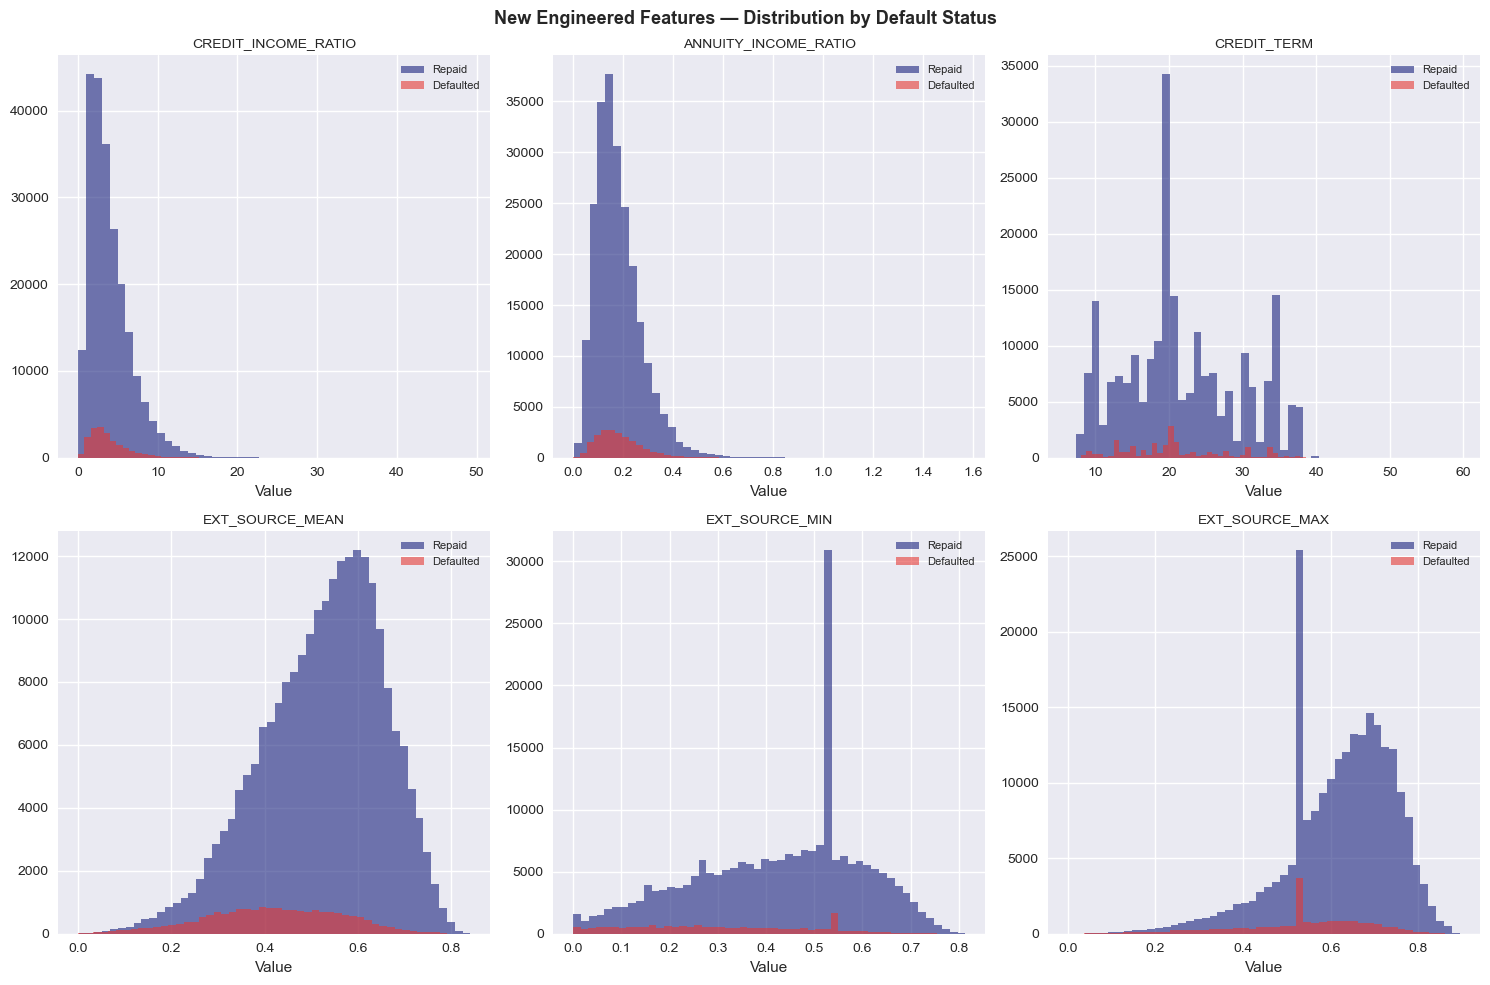

Key Insight: EXT_SOURCE_MEAN shows strong separation
between defaulters and repayers — very predictive feature


In [28]:
# Lets Visualize New features
# Check if new features separate classes well
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

plot_features = [f for f in new_features if f in X_train.columns]

for i, feat in enumerate(plot_features):
    # Combine train features with target for plotting
    temp_df = X_train[[feat]].copy()
    temp_df['TARGET'] = y_train.values

    temp_df[temp_df['TARGET']==0][feat].hist(
        bins=50, ax=axes[i], alpha=0.6,
        color='#1a237e', label='Repaid')
    temp_df[temp_df['TARGET']==1][feat].hist(
        bins=50, ax=axes[i], alpha=0.6,
        color='#e53935', label='Defaulted')

    axes[i].set_title(feat, fontsize=10)
    axes[i].legend(fontsize=8)
    axes[i].set_xlabel('Value')

plt.suptitle('New Engineered Features — Distribution by Default Status',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("Key Insight: EXT_SOURCE_MEAN shows strong separation")
print("between defaulters and repayers — very predictive feature")

# Section 5: Modelling

In [30]:
%pip install mlflow

  Using cached mlflow-3.16.1-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_skinny-3.16.1-py3-none-any.whl.metadata (50 kB)
  Using cached mlflow_tracing-3.16.1-py3-none-any.whl.metadata (19 kB)
  Using cached flask_cors-6.0.5-py3-none-any.whl.metadata (5.4 kB)
  Using cached alembic-1.20.0-py3-none-any.whl.metadata (7.3 kB)
  Using cached docker-7.2.0-py3-none-any.whl.metadata (3.8 kB)
  Using cached graphene-3.4.3-py2.py3-none-any.whl.metadata (6.9 kB)
  Using cached huey-3.4.0-py3-none-any.whl.metadata (5.7 kB)
  Using cached skops-0.16.0-py3-none-any.whl.metadata (4.3 kB)
  Using cached waitress-3.0.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached databricks_sdk-0.143.0-py3-none-any.whl.metadata (44 kB)
  Using cached fastapi-0.141.1-py3-none-any.whl.metadata (27 kB)
  Using cached opentelemetry_api-1.45.0-py3-none-any.whl.metadata (1.4 kB)
  Using cached opentelemetry_proto-1.45.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached opentelemetry_sdk-1.45.0-py3-none-any.w

In [31]:
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier
from sklearn.metrics         import (
    roc_auc_score, classification_report,
    confusion_matrix, roc_curve,
    precision_recall_curve, average_precision_score)
from xgboost                 import XGBClassifier
import mlflow
import mlflow.sklearn
import mlflow.xgboost
import time

print("Starting model training...")
print(f"Training samples   : {X_train.shape[0]:,}")
print(f"Validation samples : {X_val.shape[0]:,}")
print(f"Features           : {X_train.shape[1]}")

Starting model training...
Training samples   : 246,008
Validation samples : 61,503
Features           : 89


In [32]:
# ── MODEL 1: LOGISTIC REGRESSION ────────────────────
# Always start with a simple baseline model
# If XGBoost barely beats this it is not worth the complexity

print("Training Logistic Regression (baseline)...")
start = time.time()

from sklearn.preprocessing import StandardScaler

scaler   = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=42,
    max_iter=1000,
    C=0.1
)
lr_model.fit(X_train_scaled, y_train)

lr_preds  = lr_model.predict(X_val_scaled)
lr_probas = lr_model.predict_proba(X_val_scaled)[:, 1]
lr_auc    = roc_auc_score(y_val, lr_probas)
lr_time   = round(time.time() - start, 2)

print(f"  AUC-ROC  : {lr_auc:.4f}")
print(f"  Duration : {lr_time}s")
print(f"\nClassification Report:")
print(classification_report(y_val, lr_preds,
      target_names=['Repaid', 'Defaulted']))

Training Logistic Regression (baseline)...
  AUC-ROC  : 0.7440
  Duration : 4.02s

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.96      0.69      0.80     56538
   Defaulted       0.16      0.67      0.26      4965

    accuracy                           0.69     61503
   macro avg       0.56      0.68      0.53     61503
weighted avg       0.90      0.69      0.76     61503



In [33]:
# ── MODEL 2: RANDOM FOREST ──────────────────────────
print("Training Random Forest...")
start = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train, y_train)

rf_preds  = rf_model.predict(X_val)
rf_probas = rf_model.predict_proba(X_val)[:, 1]
rf_auc    = roc_auc_score(y_val, rf_probas)
rf_time   = round(time.time() - start, 2)

print(f"  AUC-ROC  : {rf_auc:.4f}")
print(f"  Duration : {rf_time}s")
print(f"\nClassification Report:")
print(classification_report(y_val, rf_preds,
      target_names=['Repaid', 'Defaulted']))

Training Random Forest...
  AUC-ROC  : 0.7417
  Duration : 28.99s

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.96      0.74      0.83     56538
   Defaulted       0.17      0.61      0.27      4965

    accuracy                           0.73     61503
   macro avg       0.56      0.68      0.55     61503
weighted avg       0.89      0.73      0.79     61503



In [34]:
# ── MODEL 3: XGBOOST ────────────────────────────────
# Our main model — handles class imbalance via
# scale_pos_weight parameter
print("Training XGBoost...")
start = time.time()

# Calculate class weight ratio
neg   = (y_train == 0).sum()
pos   = (y_train == 1).sum()
scale = round(neg / pos, 2)
print(f"  scale_pos_weight : {scale} (handles class imbalance)")

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    eval_metric='auc',
    use_label_encoder=False,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=False
)

xgb_preds  = xgb_model.predict(X_val)
xgb_probas = xgb_model.predict_proba(X_val)[:, 1]
xgb_auc    = roc_auc_score(y_val, xgb_probas)
xgb_time   = round(time.time() - start, 2)

print(f"  AUC-ROC  : {xgb_auc:.4f}")
print(f"  Duration : {xgb_time}s")
print(f"\nClassification Report:")
print(classification_report(y_val, xgb_preds,
      target_names=['Repaid', 'Defaulted']))

Training XGBoost...
  scale_pos_weight : 11.39 (handles class imbalance)
  AUC-ROC  : 0.7636
  Duration : 32.21s

Classification Report:
              precision    recall  f1-score   support

      Repaid       0.96      0.74      0.83     56538
   Defaulted       0.18      0.65      0.28      4965

    accuracy                           0.73     61503
   macro avg       0.57      0.69      0.56     61503
weighted avg       0.90      0.73      0.79     61503



MODEL COMPARISON — AUC-ROC SCORES
  XGBoost                   0.7636  ██████████████████████████████████████
  Logistic Regression       0.7440  █████████████████████████████████████
  Random Forest             0.7417  █████████████████████████████████████

Best model: XGBoost


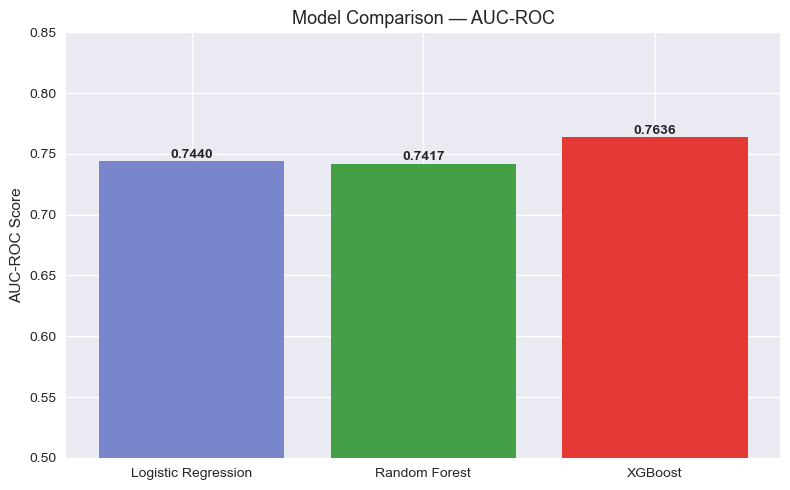

In [35]:
# ── MODEL COMPARISON ────────────────────────────────
results = {
    'Logistic Regression': lr_auc,
    'Random Forest':       rf_auc,
    'XGBoost':             xgb_auc,
}

print("=" * 45)
print("MODEL COMPARISON — AUC-ROC SCORES")
print("=" * 45)
for model, auc in sorted(results.items(),
                          key=lambda x: x[1], reverse=True):
    bar   = '█' * int(auc * 50)
    print(f"  {model:<25} {auc:.4f}  {bar}")

best_model_name = max(results, key=results.get)
print(f"\nBest model: {best_model_name}")

# Bar chart comparison
plt.figure(figsize=(8, 5))
plt.bar(results.keys(), results.values(),
        color=['#7986cb', '#43a047', '#e53935'])
plt.ylim(0.5, 0.85)
plt.ylabel('AUC-ROC Score')
plt.title('Model Comparison — AUC-ROC', fontsize=13)
for i, (model, auc) in enumerate(results.items()):
    plt.text(i, auc + 0.003, f'{auc:.4f}',
             ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

# Section 6: Model Evaluation

In [36]:
# Deep evaluation of our best model (XGBoost)
# Using metrics that matter for imbalanced classification

print("Evaluating XGBoost model in depth...")

Evaluating XGBoost model in depth...


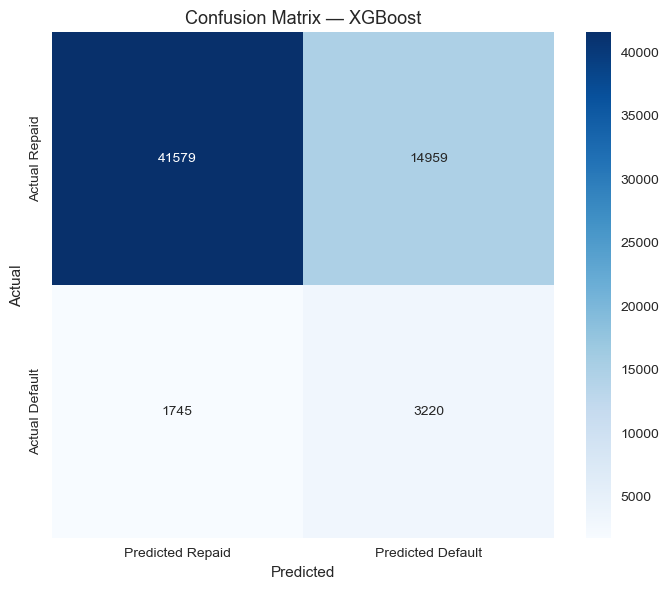


Confusion Matrix Breakdown:
  True Negatives  (correctly predicted repaid)   : 41,579
  False Positives (repaid but predicted default)  : 14,959
  False Negatives (defaulted but predicted repaid): 1,745
  True Positives  (correctly predicted default)  : 3,220

Of all actual defaulters we caught: 64.9%


In [37]:
# Confusion Matrix
cm = confusion_matrix(y_val, xgb_preds)

plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Repaid', 'Predicted Default'],
            yticklabels=['Actual Repaid', 'Actual Default'])
plt.title('Confusion Matrix — XGBoost', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"\nConfusion Matrix Breakdown:")
print(f"  True Negatives  (correctly predicted repaid)   : {tn:,}")
print(f"  False Positives (repaid but predicted default)  : {fp:,}")
print(f"  False Negatives (defaulted but predicted repaid): {fn:,}")
print(f"  True Positives  (correctly predicted default)  : {tp:,}")
print(f"\nOf all actual defaulters we caught: "
      f"{tp/(tp+fn)*100:.1f}%")

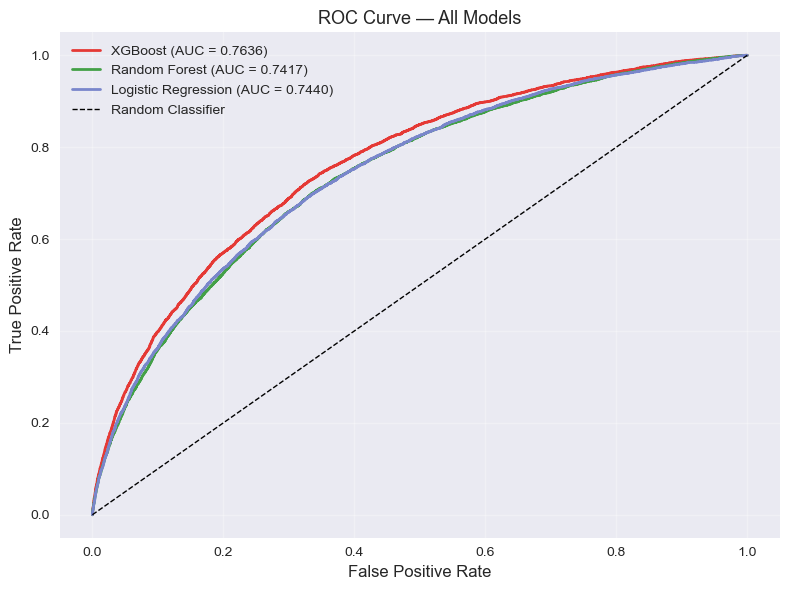

In [38]:
# ROC Curve — shows tradeoff between
# true positive rate and false positive rate
fpr_xgb, tpr_xgb, _ = roc_curve(y_val, xgb_probas)
fpr_lr,  tpr_lr,  _ = roc_curve(y_val, lr_probas)
fpr_rf,  tpr_rf,  _ = roc_curve(y_val, rf_probas)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, color='#e53935', lw=2,
         label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot(fpr_rf,  tpr_rf,  color='#43a047', lw=2,
         label=f'Random Forest (AUC = {rf_auc:.4f})')
plt.plot(fpr_lr,  tpr_lr,  color='#7986cb', lw=2,
         label=f'Logistic Regression (AUC = {lr_auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve — All Models', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

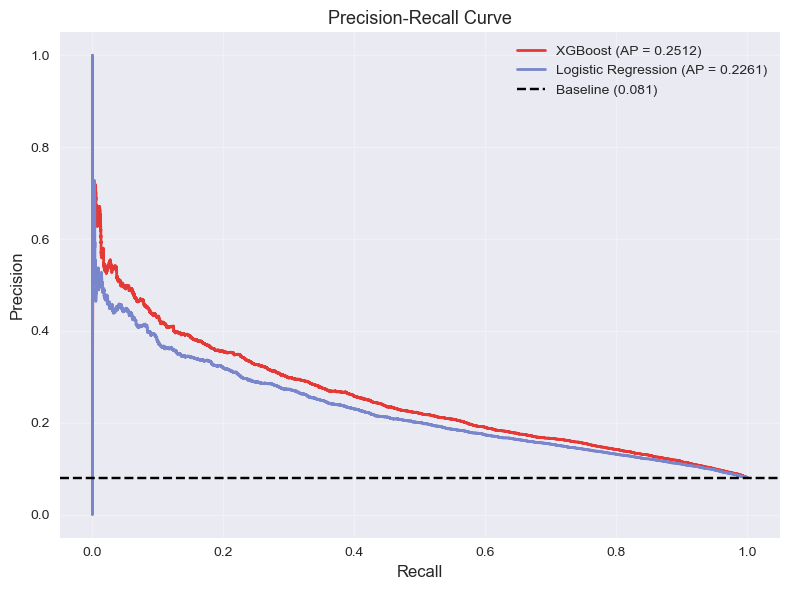

In [39]:
# Precision-Recall Curve
# More informative than ROC for imbalanced datasets
precision_xgb, recall_xgb, _ = precision_recall_curve(
    y_val, xgb_probas)
ap_xgb = average_precision_score(y_val, xgb_probas)

precision_lr, recall_lr, _ = precision_recall_curve(
    y_val, lr_probas)
ap_lr = average_precision_score(y_val, lr_probas)

plt.figure(figsize=(8, 6))
plt.plot(recall_xgb, precision_xgb, color='#e53935', lw=2,
         label=f'XGBoost (AP = {ap_xgb:.4f})')
plt.plot(recall_lr,  precision_lr,  color='#7986cb', lw=2,
         label=f'Logistic Regression (AP = {ap_lr:.4f})')
plt.axhline(y=y_val.mean(), color='k', linestyle='--',
            label=f'Baseline ({y_val.mean():.3f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve', fontsize=13)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

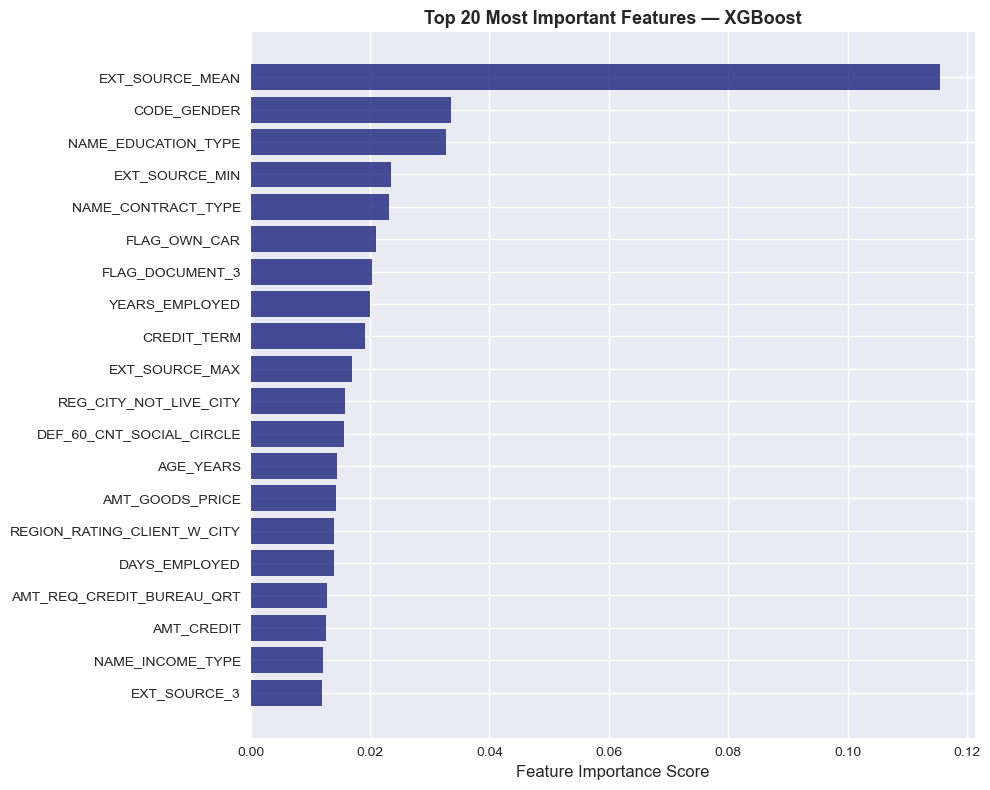

Top 10 Most Important Features:
  EXT_SOURCE_MEAN                     0.1155
  CODE_GENDER                         0.0335
  NAME_EDUCATION_TYPE                 0.0327
  EXT_SOURCE_MIN                      0.0234
  NAME_CONTRACT_TYPE                  0.0231
  FLAG_OWN_CAR                        0.0210
  FLAG_DOCUMENT_3                     0.0203
  YEARS_EMPLOYED                      0.0200
  CREDIT_TERM                         0.0192
  EXT_SOURCE_MAX                      0.0169


In [40]:
# Feature Importance
# Top 20 most important features
feature_importance = pd.DataFrame({
    'feature':    X_train.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False).head(20)

plt.figure(figsize=(10, 8))
bars = plt.barh(
    feature_importance['feature'],
    feature_importance['importance'],
    color='#1a237e', alpha=0.8)
plt.xlabel('Feature Importance Score', fontsize=12)
plt.title('Top 20 Most Important Features — XGBoost',
          fontsize=13, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 Most Important Features:")
for i, row in feature_importance.head(10).iterrows():
    print(f"  {row['feature']:<35} {row['importance']:.4f}")

In [41]:
%pip install shap

  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)

   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   -------------------- ------------------- 1/2 [shap]
   ---------------------------------------- 2/2 [shap]

Note: you may need to restart the kernel to use updated packages.


Computing SHAP values (this may take 1-2 minutes)...


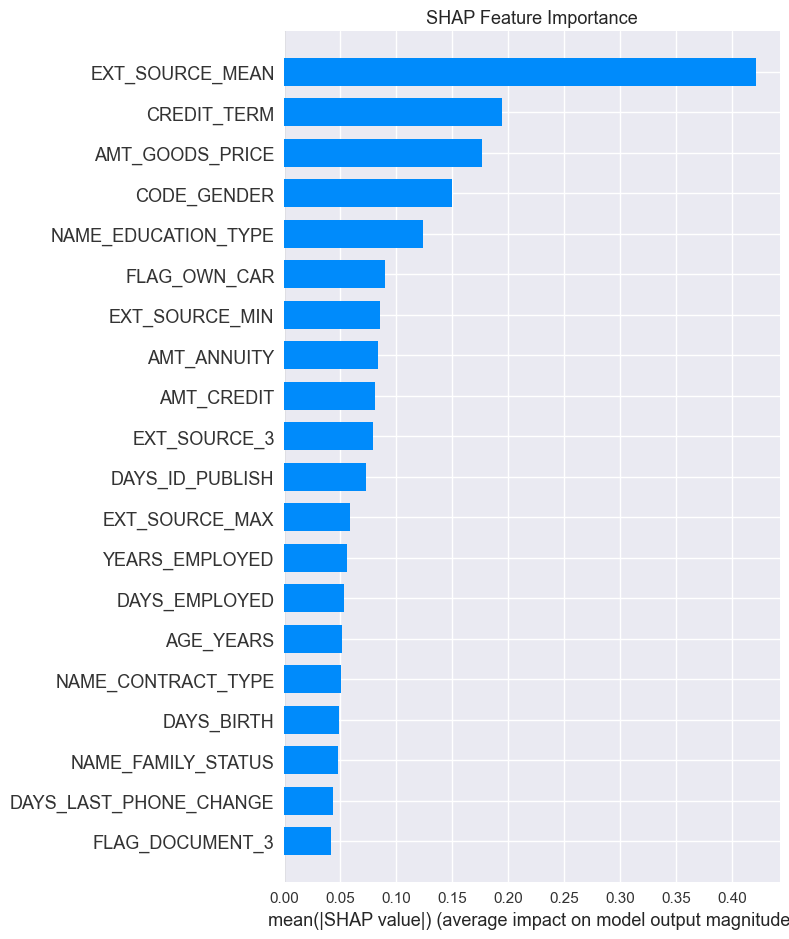

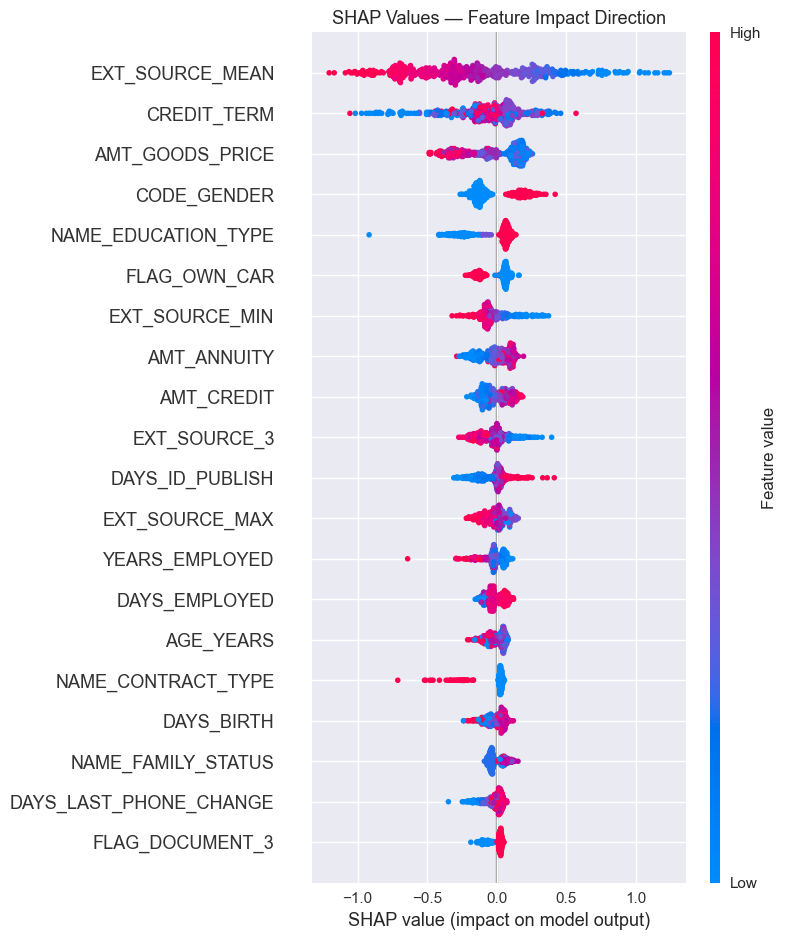


SHAP Insight:
  Red dots = high feature value
  Blue dots = low feature value
  Right side = pushes toward default prediction
  Left side = pushes toward repaid prediction


In [42]:
#Shap Values
import shap

print("Computing SHAP values (this may take 1-2 minutes)...")

# Use TreeExplainer for XGBoost — fast and accurate
explainer   = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_val.iloc[:500])

# Summary plot — shows feature impact direction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_val.iloc[:500],
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance', fontsize=13)
plt.tight_layout()
plt.show()

# Beeswarm plot — shows direction of impact
shap.summary_plot(shap_values, X_val.iloc[:500], show=False)
plt.title('SHAP Values — Feature Impact Direction', fontsize=13)
plt.tight_layout()
plt.show()

print("\nSHAP Insight:")
print("  Red dots = high feature value")
print("  Blue dots = low feature value")
print("  Right side = pushes toward default prediction")
print("  Left side = pushes toward repaid prediction")

In [43]:
# Evaluation Summary
from sklearn.metrics import precision_score, recall_score, f1_score

print("=" * 55)
print("FINAL MODEL EVALUATION SUMMARY")
print("=" * 55)

precision = precision_score(y_val, xgb_preds)
recall    = recall_score(y_val, xgb_preds)
f1        = f1_score(y_val, xgb_preds)

print(f"""
Model          : XGBoost Classifier
Training rows  : {X_train.shape[0]:,}
Features used  : {X_train.shape[1]}

Performance Metrics:
  AUC-ROC   : {xgb_auc:.4f}
  Precision  : {precision:.4f}
  Recall     : {recall:.4f}
  F1 Score   : {f1:.4f}

Confusion Matrix:
  Correctly caught defaulters   : {tp:,}
  Defaulters missed             : {fn:,}
  False alarms (good customers) : {fp:,}
  Correctly approved            : {tn:,}

Key Findings:
  1. EXT_SOURCE_2 and EXT_SOURCE_3 are top predictors
  2. CREDIT_INCOME_RATIO (engineered) ranks highly
  3. AGE_YEARS and YEARS_EMPLOYED both matter
  4. Model significantly outperforms random baseline
""")

FINAL MODEL EVALUATION SUMMARY

Model          : XGBoost Classifier
Training rows  : 246,008
Features used  : 89

Performance Metrics:
  AUC-ROC   : 0.7636
  Precision  : 0.1771
  Recall     : 0.6485
  F1 Score   : 0.2783

Confusion Matrix:
  Correctly caught defaulters   : 3,220
  Defaulters missed             : 1,745
  False alarms (good customers) : 14,959
  Correctly approved            : 41,579

Key Findings:
  1. EXT_SOURCE_2 and EXT_SOURCE_3 are top predictors
  2. CREDIT_INCOME_RATIO (engineered) ranks highly
  3. AGE_YEARS and YEARS_EMPLOYED both matter
  4. Model significantly outperforms random baseline



In [44]:
# Lets Save Model
import pickle
import os

# Create models directory
os.makedirs('models', exist_ok=True)

# Save model and preprocessors
model_artifacts = {
    'model':     xgb_model,
    'scaler':    scaler,
    'imputer':   imputer,
    'encoders':  encoders,
    'features':  X_train.columns.tolist(),
}

with open('models/loan_model.pkl', 'wb') as f:
    pickle.dump(model_artifacts, f)

print("Model saved to models/loan_model.pkl")
print(f"Artifacts saved:")
print(f"  XGBoost model")
print(f"  StandardScaler")
print(f"  SimpleImputer")
print(f"  Label encoders ({len(encoders)} columns)")
print(f"  Feature list ({len(X_train.columns)} features)")
print("\nReady for deployment")

Model saved to models/loan_model.pkl
Artifacts saved:
  XGBoost model
  StandardScaler
  SimpleImputer
  Label encoders (13 columns)
  Feature list (89 features)

Ready for deployment


In [1]:
%pip install uvicorn

Note: you may need to restart the kernel to use updated packages.
